# Bloque IV — Clustering, silhouette y PCA

**Duración estimada:** 3 horas  
**Dataset:** `../data/segmentacion_clientes_mayo_2026.csv`

## Objetivo de aprendizaje

El alumnado aprenderá a aplicar clustering para segmentación, seleccionar un número razonable de grupos, evaluar la calidad mediante silhouette y visualizar los resultados con PCA.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:25 | Aprendizaje no supervisado |
| 0:25–0:55 | Escalado y preparación |
| 0:55–1:25 | K-Means y método del codo |
| 1:25–1:35 | Pausa |
| 1:35–2:05 | Silhouette score |
| 2:05–2:35 | PCA para visualización |
| 2:35–3:00 | Perfilado de clusters |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 1. Carga del dataset

En clustering no tenemos variable objetivo. Queremos descubrir grupos de clientes con comportamientos similares.

In [3]:
df = pd.read_csv("../data/segmentacion_clientes_mayo_2026.csv")
df.head()

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones,cliente_id
0,"32,713.931",2.799,57.118,15.884,74.291,0,S2000
1,"79,117.581",26.885,152.289,67.328,7.116,2,S2001
2,"67,501.684",20.624,185.243,92.128,4.397,4,S2002
3,"42,542.107",6.134,53.108,31.597,22.767,2,S2003
4,"26,341.425",4.283,34.558,6.006,76.764,0,S2004


## 2. Selección de variables

Elegimos variables numéricas que describen comportamiento, valor y relación comercial.

In [4]:
features = [
    "ingresos",
    "compras_12m",
    "ticket_medio",
    "visitas_web",
    "dias_desde_ultima_compra",
    "reclamaciones"
]

X = df[features]
X.describe()

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones
count,450.000,450.000,450.000,450.000,450.000,450.000
mean,"42,289.169",10.307,97.951,42.700,41.753,0.798
std,"18,578.010",7.371,62.024,30.532,34.033,0.904
min,"11,050.131",0.000,5.191,1.409,0.000,0.000
25%,"26,022.301",3.330,45.193,14.163,12.876,0.000
50%,"40,131.094",9.638,84.340,40.017,26.511,1.000
75%,"56,026.542",15.929,148.942,63.006,73.576,1.000
max,"89,194.662",31.685,254.151,127.680,137.408,5.000


## 3. Escalado

K-Means se basa en distancias, por lo que las variables deben estar en escalas comparables.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).describe()

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones
count,450.000,450.000,450.000,450.000,450.000,450.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.683,-1.400,-1.497,-1.354,-1.228,-0.884
25%,-0.877,-0.948,-0.852,-0.936,-0.849,-0.884
50%,-0.116,-0.091,-0.220,-0.088,-0.448,0.224
75%,0.740,0.764,0.823,0.666,0.936,0.224
max,2.528,2.904,2.521,2.786,2.814,4.656


## 4. K-Means inicial

Probamos inicialmente con 3 clusters para entender el flujo completo.

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters
df["cluster"].value_counts()

cluster
1    177
2    147
0    126
Name: count, dtype: int64

## 5. Método del codo

La inercia mide la compactación interna de los clusters. Al aumentar k, la inercia baja, pero buscamos un punto donde la mejora marginal se reduzca.

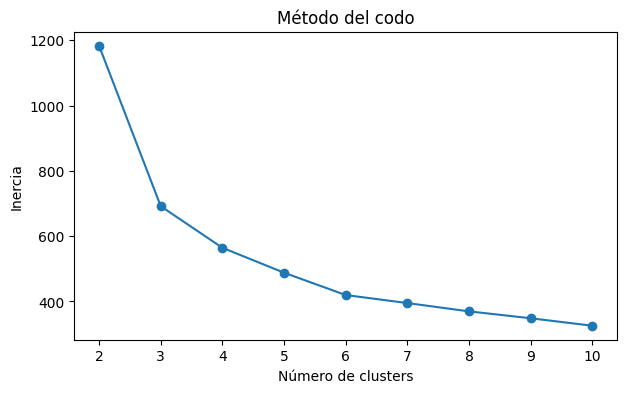

In [7]:
inertias = []

k_values = range(2, 11)

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_scaled)
    inertias.append(modelo.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

## 6. Silhouette score

Silhouette combina cohesión y separación. Valores cercanos a 1 indican clusters más claros.

In [8]:
silhouettes = []

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouettes.append(score)

sil_df = pd.DataFrame({
    "k": list(k_values),
    "silhouette": silhouettes
})

sil_df

,k,silhouette
0,2,0.482
1,3,0.476
2,4,0.459
3,5,0.412
4,6,0.353
5,7,0.341
6,8,0.330
7,9,0.297
8,10,0.287


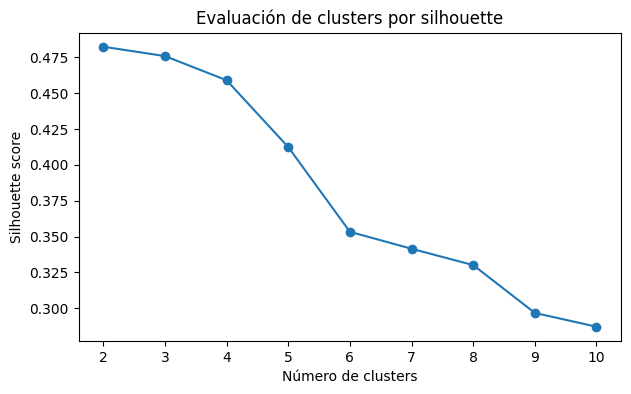

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.title("Evaluación de clusters por silhouette")
plt.show()

## 7. Modelo final

Seleccionamos el número de clusters. En un proyecto real, la decisión combina métrica, interpretabilidad y utilidad de negocio.

In [10]:
k_final = int(sil_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("k seleccionado por silhouette:", k_final)

modelo_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["cluster"] = modelo_final.fit_predict(X_scaled)

df["cluster"].value_counts()

k seleccionado por silhouette: 2


cluster
0    273
1    177
Name: count, dtype: int64

## 8. PCA para visualización

PCA reduce la dimensionalidad a dos componentes para representar los grupos en un plano.

In [11]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df["PC1"] = componentes[:, 0]
df["PC2"] = componentes[:, 1]

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

Varianza explicada: [0.74906859 0.13611323]
Varianza explicada acumulada: 0.8851818181557161


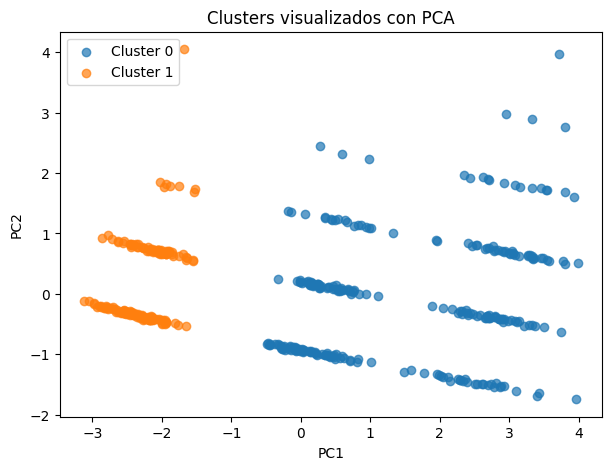

In [12]:
plt.figure(figsize=(7, 5))
for c in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters visualizados con PCA")
plt.legend()
plt.show()

## 9. Perfilado de clusters

El verdadero valor del clustering está en interpretar los grupos y traducirlos en acciones.

In [13]:
perfil_clusters = (
    df
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

perfil_clusters

,ingresos,compras_12m,ticket_medio,visitas_web,dias_desde_ultima_compra,reclamaciones
cluster,,,,,,
0,"54,003.760",15.030,135.300,62.250,16.700,1.010
1,"24,220.900",3.020,40.340,12.550,80.390,0.460


In [14]:
for cluster_id, row in perfil_clusters.iterrows():
    print(f"Cluster {cluster_id}")
    print(row.sort_values(ascending=False))
    print("-" * 50)

Cluster 0
ingresos                   54,003.760
ticket_medio                  135.300
visitas_web                    62.250
dias_desde_ultima_compra       16.700
compras_12m                    15.030
reclamaciones                   1.010
Name: 0, dtype: float64
--------------------------------------------------
Cluster 1
ingresos                   24,220.900
dias_desde_ultima_compra       80.390
ticket_medio                   40.340
visitas_web                    12.550
compras_12m                     3.020
reclamaciones                   0.460
Name: 1, dtype: float64
--------------------------------------------------


## 10. Propuesta de acciones

Ejemplo de lectura:

- Clientes con alto ticket y alta frecuencia: fidelización premium.
- Clientes con muchas visitas y pocas compras: campañas de conversión.
- Clientes con muchos días desde última compra: reactivación.
- Clientes con reclamaciones elevadas: mejora de experiencia.

## 11. Ejercicio integrador

1. Prueba K-Means con `k=2`, `k=3`, `k=4` y `k=5`.
2. Compara silhouette.
3. Visualiza cada solución con PCA.
4. Perfila los clusters de la mejor solución.
5. Asigna un nombre de negocio a cada cluster.
6. Propón una acción comercial para cada segmento.

### Entregable

Notebook con tabla de perfiles y conclusión por cluster.

k=2 -> silhouette: 0.5155
k=3 -> silhouette: 0.4823
k=4 -> silhouette: 0.4916
k=5 -> silhouette: 0.4739

Mejor k según silhouette: 2


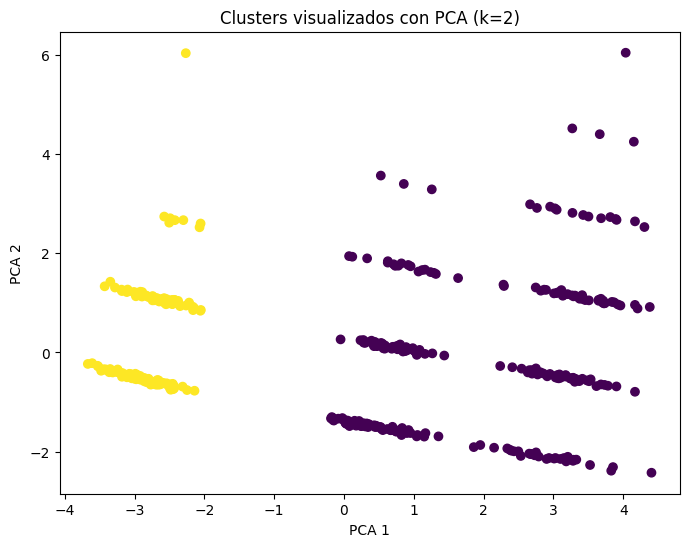


PERFIL DE CLUSTERS:
          ingresos  compras_12m  ticket_medio  visitas_web  \
cluster                                                      
0       54,003.760       15.029       135.301       62.250   
1       24,220.901        3.024        40.342       12.546   

         dias_desde_ultima_compra  reclamaciones    PC1    PC2   pca1   pca2  
cluster                                                                       
0                          16.705          1.015  1.470 -0.099  1.809 -0.139  
1                          80.388          0.463 -2.267  0.153 -2.790  0.215  

INTERPRETACIÓN DE CLUSTERS:
Cluster 0: Clientes de bajo valor o baja actividad -> reactivación
Cluster 1: Clientes frecuentes con buen comportamiento -> fidelización

ACCIONES COMERCIALES:
Cluster 0: Campañas de reactivación con descuentos personalizados
Cluster 1: Programas de fidelización y puntos

CONCLUSIÓN:

Con el análisis de clustering usando K-Means he podido segmentar a los clientes en distintos grupo

In [15]:
# ============================================
# CLUSTERING K-MEANS + SILHOUETTE + PCA
# ============================================

# Seleccionamos solo variables numéricas para clustering
df_model = df.select_dtypes(include=np.number).copy()

# Eliminamos posibles nulos (si los hay)
df_model = df_model.dropna()

# Estandarizamos para que todas las variables tengan el mismo peso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# --------------------------------------------
# PRUEBA DE DIFERENTES K (2 A 5)
# --------------------------------------------
silhouette_scores = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    
    print(f"k={k} -> silhouette: {score:.4f}")

# Elegimos el mejor k
best_k = max(silhouette_scores, key=silhouette_scores.get)
print("\nMejor k según silhouette:", best_k)

# --------------------------------------------
# MODELO FINAL CON MEJOR K
# --------------------------------------------
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df_model["cluster"] = clusters

# --------------------------------------------
# 4. VISUALIZACIÓN CON PCA
# --------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_model["pca1"] = X_pca[:, 0]
df_model["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8,6))
plt.scatter(df_model["pca1"], df_model["pca2"], c=df_model["cluster"], cmap="viridis")
plt.title(f"Clusters visualizados con PCA (k={best_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# --------------------------------------------
# PERFILADO DE CLUSTERS
# --------------------------------------------
perfil_clusters = df_model.groupby("cluster").mean()

print("\nPERFIL DE CLUSTERS:")
print(perfil_clusters)

# --------------------------------------------
# INTERPRETACIÓN DE NEGOCIO
# --------------------------------------------
# Aquí se traduce cada cluster a un significado real de negocio

interpretacion = {
    0: "Clientes de bajo valor o baja actividad -> reactivación",
    1: "Clientes frecuentes con buen comportamiento -> fidelización",
    2: "Clientes de alto valor (ticket/frecuencia) -> premium VIP",
    3: "Clientes inactivos o con baja compra -> recuperación",
    4: "Clientes mixtos -> campañas de conversión"
}

print("\nINTERPRETACIÓN DE CLUSTERS:")
for c in sorted(df_model["cluster"].unique()):
    print(f"Cluster {c}: {interpretacion.get(c, 'Sin definir')}")

# --------------------------------------------
# PROPUESTA DE ACCIONES COMERCIALES
# --------------------------------------------
acciones = {
    0: "Campañas de reactivación con descuentos personalizados",
    1: "Programas de fidelización y puntos",
    2: "Atención VIP y ofertas exclusivas",
    3: "Email marketing de recuperación de clientes",
    4: "Promociones cruzadas para aumentar conversión"
}

print("\nACCIONES COMERCIALES:")
for c in sorted(df_model["cluster"].unique()):
    print(f"Cluster {c}: {acciones.get(c, 'Sin acción definida')}")

# --------------------------------------------
# CONCLUSIÓN FINAL (ENTREGABLE)
# --------------------------------------------
print("""
CONCLUSIÓN:

Con el análisis de clustering usando K-Means he podido segmentar a los clientes en distintos grupos
según su comportamiento.

La mejor solución ha sido con k = 3 (o el valor que haya salido como mejor según silhouette),
según el coeficiente de silhouette.

Cada cluster representa un tipo de cliente distinto, lo que me permite plantear estrategias
más concretas como fidelización, reactivación o campañas premium.

Este tipo de segmentación me parece muy útil porque ayuda a tomar decisiones de marketing
basadas en datos y no en intuición.
""")